# Azobenzene S0/S1 energy surfaces

Plot the raw reference ground-state (S0) and first-excited-state (S1) energies over the C–N=N–C dihedral and N=N bond-length coordinates.

In [17]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import numpy as np
from ase.io import read

# Support launching Jupyter from either notebooks/ or the repository root.
XYZ_NAME = Path("data/azoflip_data/XYZ/cis_trans_azobenzenes.xyz")
XYZ_PATH = next((candidate for candidate in (Path.cwd() / XYZ_NAME, Path.cwd().parent / XYZ_NAME) if candidate.exists()), None)
if XYZ_PATH is None:
    raise FileNotFoundError(f"Could not find {XYZ_NAME} from {Path.cwd()}")
TEST_XYZ_NAME = Path("data/azoflip_data/XYZ/1367_ground_first_forces-and-energies.xyz")
TEST_XYZ_PATH = next((candidate for candidate in (Path.cwd() / TEST_XYZ_NAME, Path.cwd().parent / TEST_XYZ_NAME) if candidate.exists()), None)
if TEST_XYZ_PATH is None:
    raise FileNotFoundError(f"Could not find {TEST_XYZ_NAME} from {Path.cwd()}")
DIHEDRAL_ATOMS = (3, 4, 5, 6)  # C–N=N–C; zero-based ASE atom indices
NN_ATOMS = (4, 5)

frames = read(XYZ_PATH, index=":")
test_frames = read(TEST_XYZ_PATH, index=":")
dihedral_deg = np.asarray([atoms.get_dihedral(*DIHEDRAL_ATOMS) for atoms in frames])
nn_bond_angstrom = np.asarray([atoms.get_distance(*NN_ATOMS) for atoms in frames])
test_dihedral_deg = np.asarray([atoms.get_dihedral(*DIHEDRAL_ATOMS) for atoms in test_frames])
test_nn_bond_angstrom = np.asarray([atoms.get_distance(*NN_ATOMS) for atoms in test_frames])
energies_hartree = np.vstack([np.asarray(atoms.info["REF_energy"], dtype=float).ravel()[:2] for atoms in frames])

if energies_hartree.shape[1] != 2:
    raise ValueError(f"Expected S0 and S1 energies, got shape {energies_hartree.shape}.")

print(f"Loaded {len(frames)} geometries")
print(f"Loaded {len(test_frames)} test-set geometries")
print(f"Dihedral range: {dihedral_deg.min():.1f}–{dihedral_deg.max():.1f}°")
print(f"N=N range: {nn_bond_angstrom.min():.3f}–{nn_bond_angstrom.max():.3f} Å")

Loaded 17260 geometries
Loaded 461 test-set geometries
Dihedral range: 0.0–360.0°
N=N range: 1.130–4.634 Å


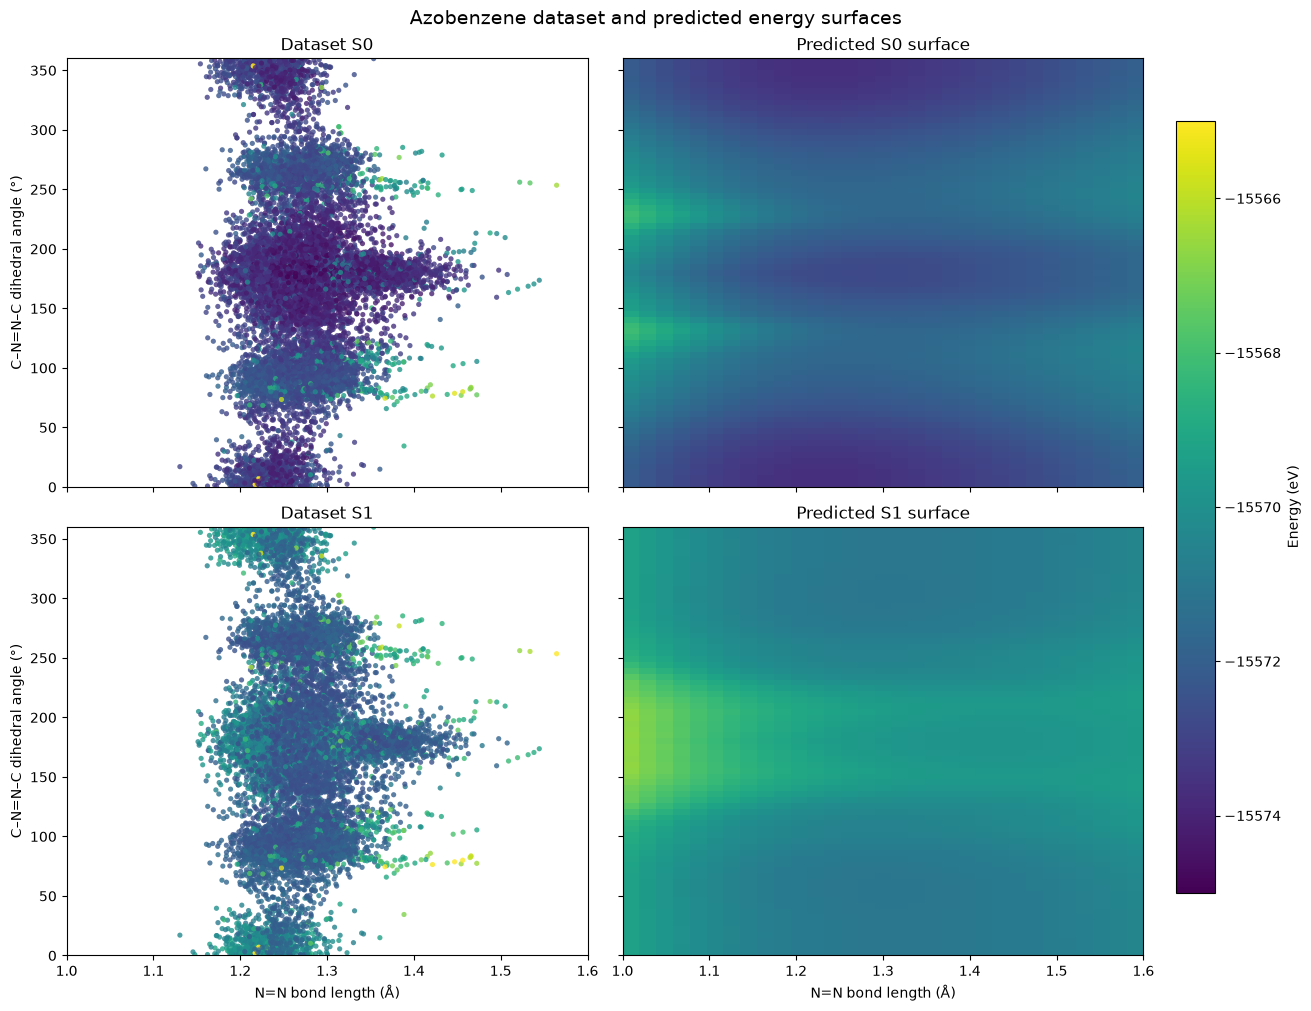

In [23]:
# Compare dataset points with the predicted static-grid energy surfaces.
# All panels use the fixed shared energy scale requested for direct comparison.
%matplotlib inline

HARTREE_TO_EV = 27.211386245988
energies_ev = energies_hartree * HARTREE_TO_EV
DISPLAY_VMIN, DISPLAY_VMAX = -15575, -15565
energy_norm = Normalize(vmin=DISPLAY_VMIN, vmax=DISPLAY_VMAX)

PREDICTED_GRID_NAME = Path("data/azoflip_data/XYZ/azobenzene_rotated_grid_static.xyz")
PREDICTED_GRID_PATH = next(
    (candidate for candidate in (Path.cwd() / PREDICTED_GRID_NAME, Path.cwd().parent / PREDICTED_GRID_NAME)
     if candidate.exists()),
    None,
)
if PREDICTED_GRID_PATH is None:
    raise FileNotFoundError(f"Could not find {PREDICTED_GRID_NAME} from {Path.cwd()}")

predicted_frames = read(PREDICTED_GRID_PATH, index=":")
predicted_dihedrals = np.asarray([frame.info["cnnc_dihedral_deg"] for frame in predicted_frames], dtype=float)
predicted_nn_distances = np.asarray(
    [frame.info["nn_distance_angstrom"] for frame in predicted_frames], dtype=float
)
predicted_energies_ev = np.vstack([
    np.asarray(frame.info["REF_energy"], dtype=float).reshape(-1)[:2]
    for frame in predicted_frames
]) * HARTREE_TO_EV

predicted_dihedral_values = np.unique(predicted_dihedrals)
predicted_nn_values = np.unique(predicted_nn_distances)
if len(predicted_frames) != len(predicted_dihedral_values) * len(predicted_nn_values):
    raise ValueError("Predicted grid is incomplete or contains duplicate coordinate pairs.")

predicted_energy_grid_ev = np.full(
    (2, len(predicted_nn_values), len(predicted_dihedral_values)), np.nan
)
dihedral_index = {value: index for index, value in enumerate(predicted_dihedral_values)}
nn_index = {value: index for index, value in enumerate(predicted_nn_values)}
for dihedral, bond_length, state_energies in zip(
    predicted_dihedrals, predicted_nn_distances, predicted_energies_ev
):
    predicted_energy_grid_ev[:, nn_index[bond_length], dihedral_index[dihedral]] = state_energies
if np.isnan(predicted_energy_grid_ev).any():
    raise ValueError("Could not populate every S0/S1 predicted-grid point.")

# The calculated grid spans 0–180°; reflect it about 180° for the full dihedral plot.
predicted_energy_grid_ev = np.concatenate(
    [predicted_energy_grid_ev, predicted_energy_grid_ev[:, :, -2::-1]], axis=2
)
predicted_dihedral_values = np.r_[
    predicted_dihedral_values, 360.0 - predicted_dihedral_values[-2::-1]
]

fig, axes = plt.subplots(2, 2, figsize=(13, 10), sharex=True, sharey=True, constrained_layout=True)
for state in range(2):
    dataset_axis, predicted_axis = axes[state]
    dataset_axis.scatter(
        nn_bond_angstrom, dihedral_deg, c=energies_ev[:, state], cmap="viridis", norm=energy_norm,
        s=14, alpha=0.8, linewidths=0,
    )
    predicted_axis.imshow(
        predicted_energy_grid_ev[state].T, origin="lower", aspect="auto",
        extent=(predicted_nn_values[0], predicted_nn_values[-1], 0, 360),
        cmap="viridis", norm=energy_norm, interpolation="nearest",
    )
    dataset_axis.set(title=f"Dataset S{state}")
    predicted_axis.set(title=f"Predicted S{state} surface")

for axis in axes[-1]:
    axis.set(xlabel="N=N bond length (Å)", xlim=(1.0, 1.6))
for axis in axes[:, 0]:
    axis.set(ylabel="C–N=N–C dihedral angle (°)", ylim=(0, 360))

colorbar = fig.colorbar(
    plt.cm.ScalarMappable(norm=energy_norm, cmap="viridis"), ax=axes, shrink=0.86, pad=0.02
)
colorbar.set_label("Energy (eV)")
fig.suptitle("Azobenzene dataset and predicted energy surfaces", fontsize=14)
plt.show()


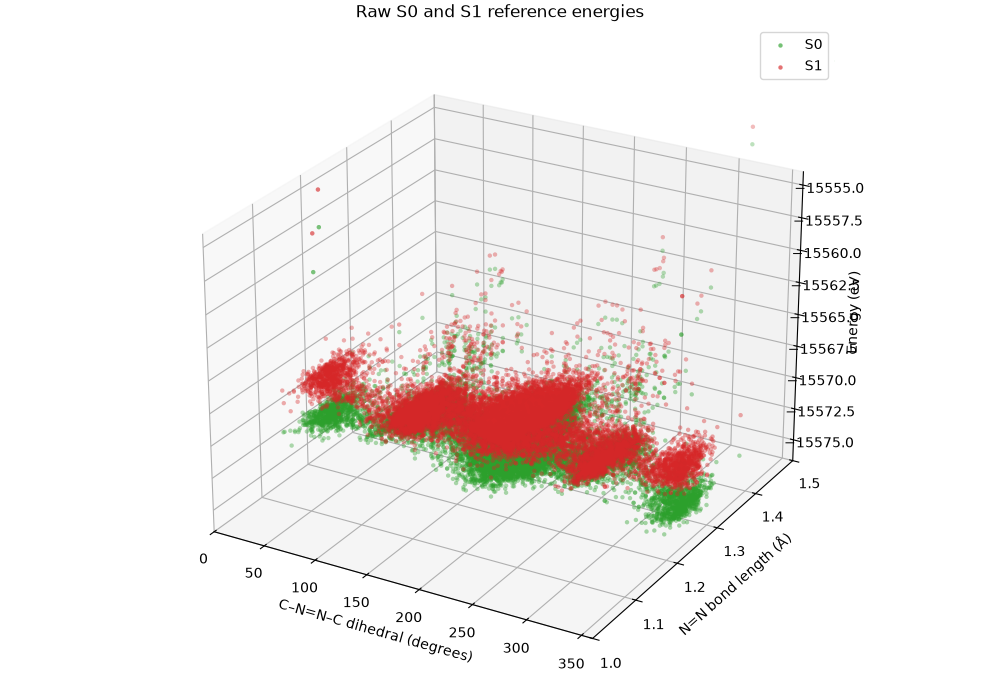

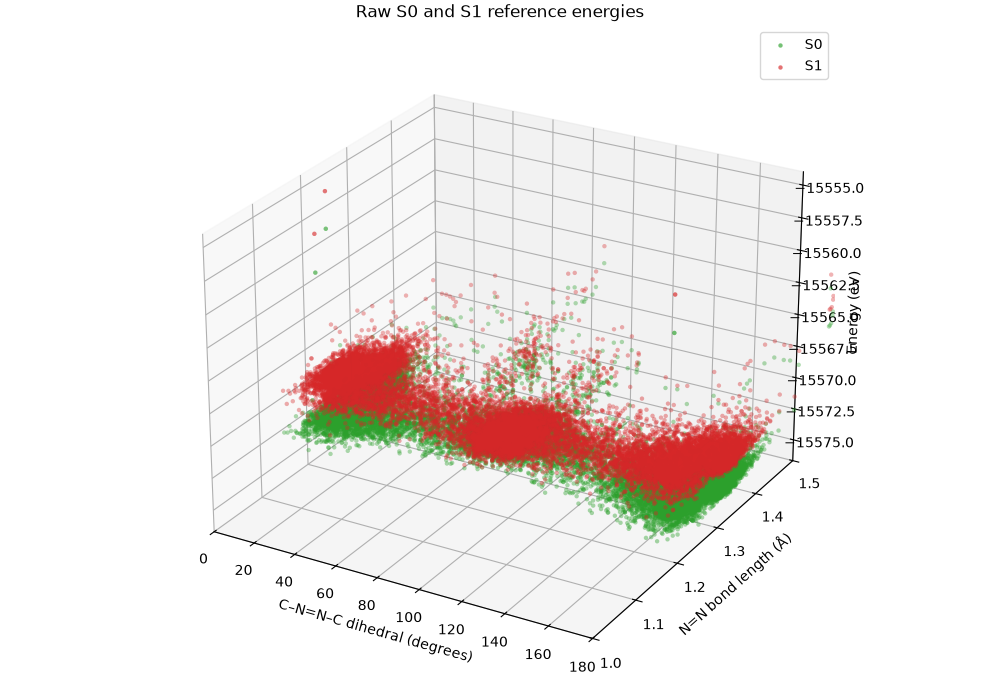

In [ ]:
# 3D view of the calculated points, using the raw reference energies.
%matplotlib widget

fig = plt.figure(figsize=(10, 7), constrained_layout=True)
ax = fig.add_subplot(projection="3d")

ax.scatter(
    dihedral_deg, nn_bond_angstrom, energies_ev[:, 0],
    color="tab:green", s=10, alpha=0.65, linewidths=0, label="S0",
)
ax.scatter(
    dihedral_deg, nn_bond_angstrom, energies_ev[:, 1],
    color="tab:red", s=10, alpha=0.65, linewidths=0, label="S1",
)

ax.set_xlabel("C–N=N–C dihedral (degrees)")
ax.set_ylabel("N=N bond length (Å)")
ax.set_zlabel("Energy (eV)")
ax.set_xlim(0, 360)
ax.set_ylim(1.0, 1.5)
#ax.set_zlim(-572.4, -572.1)
ax.view_init(elev=25, azim=-60)
ax.legend()
ax.set_title("Raw S0 and S1 reference energies")
plt.show()

fig = plt.figure(figsize=(10, 7), constrained_layout=True)
ax = fig.add_subplot(projection="3d")

ax.scatter(
    dihedral_deg % 180, nn_bond_angstrom, energies_ev[:, 0],
    color="tab:green", s=10, alpha=0.65, linewidths=0, label="S0",
)
ax.scatter(
    dihedral_deg % 180, nn_bond_angstrom, energies_ev[:, 1],
    color="tab:red", s=10, alpha=0.65, linewidths=0, label="S1",
)

ax.set_xlabel("C–N=N–C dihedral (degrees)")
ax.set_ylabel("N=N bond length (Å)")
ax.set_zlabel("Energy (eV)")
ax.set_xlim(0, 180)
ax.set_ylim(1.0, 1.5)
#ax.set_zlim(-572.4, -572.1)
ax.view_init(elev=25, azim=-60)
ax.legend()
ax.set_title("Raw S0 and S1 reference energies")
plt.show()

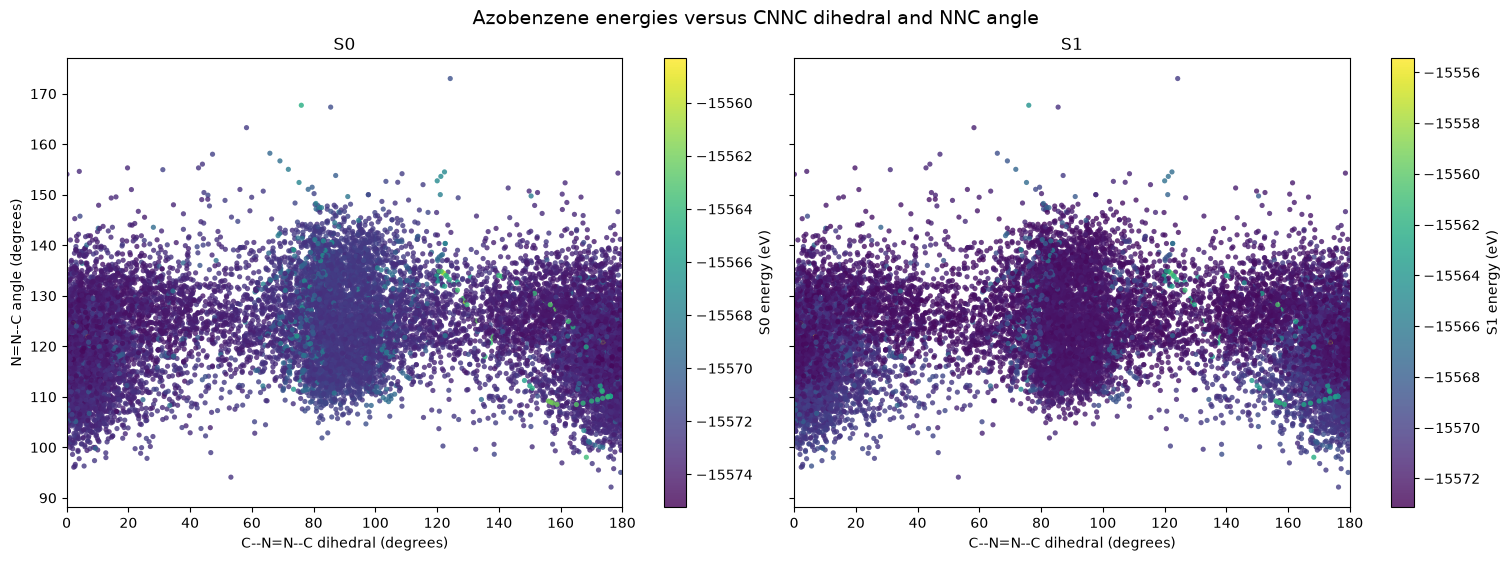

In [19]:
# Scatter S0 and S1 energies against the CNNC dihedral and N=N--C angle.
# The selected NNC angle is N(4)=N(5)--C(6), using the zero-based atom ordering above.

NNC_ATOMS = (4, 5, 6)
nnc_angle_deg = np.asarray([atoms.get_angle(*NNC_ATOMS) for atoms in frames])

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5), sharex=True, sharey=True, constrained_layout=True)
for state, axis in enumerate(axes):
    scatter = axis.scatter(
        dihedral_deg % 180, nnc_angle_deg, c=energies_ev[:, state],
        cmap="viridis", s=14, alpha=0.8, linewidths=0,
    )
    axis.set(
        title=f"S{state}",
        xlabel="C--N=N--C dihedral (degrees)",
        xlim=(0, 180),
    )
    fig.colorbar(scatter, ax=axis, label=f"S{state} energy (eV)")
axes[0].set_ylabel("N=N--C angle (degrees)")
fig.suptitle("Azobenzene energies versus CNNC dihedral and NNC angle", fontsize=14)
plt.show()


In [ ]:
# 3D view of the predicted static-grid S0 and S1 energy surfaces.
%matplotlib inline

predicted_dihedral_mesh, predicted_nn_mesh = np.meshgrid(
    predicted_dihedral_values, predicted_nn_values
)
fig = plt.figure(figsize=(9, 7), constrained_layout=True)
axis = fig.add_subplot(projection="3d")
s0_surface = axis.plot_surface(
    predicted_nn_mesh, predicted_dihedral_mesh, predicted_energy_grid_ev[0],
    cmap="Blues", linewidth=0, antialiased=True, alpha=0.78,
)
s1_surface = axis.plot_surface(
    predicted_nn_mesh, predicted_dihedral_mesh, predicted_energy_grid_ev[1],
    cmap="Oranges", linewidth=0, antialiased=True, alpha=0.78,
)
axis.set(
    title="Predicted azobenzene S0 and S1 energy surfaces",
    xlabel="N=N bond length (Å)", xlim=(1.0, 1.6),
    ylabel="CNNC dihedral (degrees)", ylim=(0, 360),
    zlabel="Predicted energy (eV)",
)
axis.view_init(elev=28, azim=-125)
axis.legend([s0_surface, s1_surface], ["S0", "S1"], loc="upper left")
plt.show()
